In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

os.listdir('/content/drive/MyDrive')

['Colab Notebooks',
 'DISK1 (1)',
 'DISK1',
 'Classroom',
 'Lecture 1 -- Listening Skills.gdoc',
 'UNIT 3 - CEMENT & POP (1).gdoc',
 'IR.gdoc',
 'NewDoc07-23-202410.28.gdoc',
 'Screenshot 2024-09-23 232453.png',
 'Bubble Sort (3).gdoc',
 'Bubble Sort (2).gdoc',
 'Bubble Sort (1).gdoc',
 'Bubble Sort.gdoc',
 'Counting Sort.gdoc',
 'W1.gslides',
 'W7.L1.gslides',
 'WhatsApp Image 2024-11-22 at 4.21.57 PM.jpeg',
 'python-01.pdf',
 'python-02.pdf',
 'MYRESUME.may.docx',
 'Document from Vidhi Sharma',
 'Screenshot 2025-06-02 121603.png',
 'Screenshot 2025-06-02 121632.png',
 'Event Registration.gform',
 'Vidhi_RESUME.docx',
 'AI Framework for Sustainable Packaging Design and Material Optimization .pdf',
 'archive (2).zip',
 'archive (3).zip',
 'archive (1).zip',
 'Screenshot_2026-02-10-10-37-20-41_40deb401b9ffe8e1df2f1cc5ba480b12.jpg',
 'Screenshot 2026-02-17 120337.png',
 'Screenshot 2026-02-17 120357.png',
 'Satellite dataset.zip']

In [ ]:
!cp "/content/drive/MyDrive/Satellite dataset.zip" /content/

In [ ]:
import zipfile

with zipfile.ZipFile('/content/Satellite dataset.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/')

In [ ]:
os.listdir('/content/')

['.config',
 'Satellite dataset.zip',
 'EuroSAT',
 'drive',
 'EuroSATallBands',
 'sample_data']

In [ ]:
import shutil
import random

In [ ]:
# paths
dataset_path = '/content/EuroSAT'   # your original dataset
output_path = '/content/split_data'

train_path = os.path.join(output_path, 'train')
test_path = os.path.join(output_path, 'test')
val_path = os.path.join(output_path, 'val')

In [ ]:

for path in [train_path, test_path, val_path]:
    os.makedirs(path, exist_ok=True)

In [ ]:

classes = os.listdir(dataset_path)

In [ ]:
for cls in classes:
    cls_path = os.path.join(dataset_path, cls)

    if not os.path.isdir(cls_path):
        continue

    images = os.listdir(cls_path)

    random.shuffle(images)


    total = len(images)


    train_size = int(0.7 * total)
    test_size = int(0.2 * total)

    train_imgs = images[:train_size]
    test_imgs = images[train_size:train_size + test_size]
    val_imgs = images[train_size + test_size:]


    os.makedirs(os.path.join(train_path, cls), exist_ok=True)
    os.makedirs(os.path.join(test_path, cls), exist_ok=True)
    os.makedirs(os.path.join(val_path, cls), exist_ok=True)


    for img in train_imgs:
        shutil.copy(os.path.join(cls_path, img),
                    os.path.join(train_path, cls, img))

    for img in test_imgs:
        shutil.copy(os.path.join(cls_path, img),
                    os.path.join(test_path, cls, img))

    for img in val_imgs:
        shutil.copy(os.path.join(cls_path, img),
                    os.path.join(val_path, cls, img))

    print(f"{cls} done")

print("Dataset shuffled and split successfully ✅")

Forest done
Industrial done
PermanentCrop done
SeaLake done
Residential done
Highway done
Pasture done
AnnualCrop done
HerbaceousVegetation done
River done
Dataset shuffled and split successfully ✅


In [ ]:
folders = ['train', 'test', 'val']

for f in folders:
    os.rename(f'/content/split_data/{f}/River',
              f'/content/split_data/{f}/water_bodies')

In [ ]:
base_path = '/content/split_data'

for split in ['train', 'test', 'val']:
    total = 0
    split_path = os.path.join(base_path, split)

    for cls in os.listdir(split_path):
        cls_path = os.path.join(split_path, cls)
        if os.path.isdir(cls_path):
            total += len(os.listdir(cls_path))

    print(f"{split.upper()} total images: {total}")

TRAIN total images: 18900
TEST total images: 5400
VAL total images: 2700


In [ ]:
for split in ['train', 'test', 'val']:
    print(f"\n{split.upper()}:\n")

    split_path = f'/content/split_data/{split}'

    for cls in os.listdir(split_path):
        cls_path = os.path.join(split_path, cls)

        if os.path.isdir(cls_path):
            print(f"{cls}: {len(os.listdir(cls_path))}")


TRAIN:

Forest: 2100
Industrial: 1750
water_bodies: 1750
PermanentCrop: 1750
SeaLake: 2100
Residential: 2100
Highway: 1750
Pasture: 1400
AnnualCrop: 2100
HerbaceousVegetation: 2100

TEST:

Forest: 600
Industrial: 500
water_bodies: 500
PermanentCrop: 500
SeaLake: 600
Residential: 600
Highway: 500
Pasture: 400
AnnualCrop: 600
HerbaceousVegetation: 600

VAL:

Forest: 300
Industrial: 250
water_bodies: 250
PermanentCrop: 250
SeaLake: 300
Residential: 300
Highway: 250
Pasture: 200
AnnualCrop: 300
HerbaceousVegetation: 300


In [ ]:
total_images = 0

for split in ['train', 'test', 'val']:
    for cls in os.listdir(f'/content/split_data/{split}'):
        total_images += len(os.listdir(f'/content/split_data/{split}/{cls}'))

print("Total images after split:", total_images)

Total images after split: 27000


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (224,224)
BATCH_SIZE = 32

train_gen = ImageDataGenerator(rescale=1./255)

val_gen = ImageDataGenerator(rescale=1./255)

test_gen = ImageDataGenerator(rescale=1./255)

In [ ]:
from tensorflow.keras.applications.resnet import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (224,224)

train_gen = ImageDataGenerator(preprocessing_function=preprocess_input)
val_gen = ImageDataGenerator(preprocessing_function=preprocess_input)
test_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_data = train_gen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    batch_size=32,
    class_mode='categorical'
)

val_data = val_gen.flow_from_directory(
    val_path,
    target_size=IMG_SIZE,
    batch_size=32,
    class_mode='categorical'
)

test_data = test_gen.flow_from_directory(
    test_path,
    target_size=IMG_SIZE,
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 18900 images belonging to 10 classes.
Found 2700 images belonging to 10 classes.
Found 5400 images belonging to 10 classes.


In [ ]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models

base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

x = layers.GlobalAveragePooling2D()(base_model.output)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)
output = layers.Dense(train_data.num_classes, activation='softmax')(x)

resnet_model = models.Model(base_model.input, output)

In [ ]:
import tensorflow as tf
print("GPU Available:", tf.config.list_physical_devices('GPU'))

GPU Available: []


In [ ]:
from tensorflow.keras.optimizers import Adam

resnet_model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
resnet_history = resnet_model.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)

Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


591/591 ━━━━━━━━━━━━━━━━━━━━ 3517s 6s/step - accuracy: 0.6533 - loss: 1.0862 - val_accuracy: 0.9259 - val_loss: 0.2281
Epoch 2/5
591/591 ━━━━━━━━━━━━━━━━━━━━ 3606s 6s/step - accuracy: 0.9096 - loss: 0.2787 - val_accuracy: 0.9441 - val_loss: 0.1698
Epoch 3/5
591/591 ━━━━━━━━━━━━━━━━━━━━ 3545s 6s/step - accuracy: 0.9249 - loss: 0.2176 - val_accuracy: 0.9493 - val_loss: 0.1506
Epoch 4/5
591/591 ━━━━━━━━━━━━━━━━━━━━ 3543s 6s/step - accuracy: 0.9416 - loss: 0.1730 - val_accuracy: 0.9522 - val_loss: 0.1406
Epoch 5/5
591/591 ━━━━━━━━━━━━━━━━━━━━ 3480s 6s/step - accuracy: 0.9522 - loss: 0.1526 - val_accuracy: 0.9589 - val_loss: 0.1278


In [ ]:
resnet_loss, resnet_acc = resnet_model.evaluate(test_data)
print("ResNet Accuracy:", resnet_acc)

169/169 ━━━━━━━━━━━━━━━━━━━━ 866s 5s/step - accuracy: 0.9569 - loss: 0.1367
ResNet Accuracy: 0.9568518400192261


In [ ]:
resnet_model.save('/content/resnet_model.keras')

In [ ]:
import numpy as np

y_true = test_data.classes
y_pred_prob = resnet_model.predict(test_data)
y_pred = np.argmax(y_pred_prob, axis=1)

169/169 ━━━━━━━━━━━━━━━━━━━━ 871s 5s/step


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    cohen_kappa_score,
    mean_squared_error,
    mean_absolute_error,
    classification_report,
    confusion_matrix
)

In [ ]:
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')
kappa = cohen_kappa_score(y_true, y_pred)

mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_true, y_pred)

print("ResNet Results:")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("Cohen Kappa:", kappa)
print("MSE:", mse)
print("RMSE:", rmse)
print("MAE:", mae)

ResNet Results:
Accuracy: 0.9568518518518518
Precision: 0.9571062915709072
Recall: 0.9568518518518518
F1 Score: 0.9568722023235181
Cohen Kappa: 0.9519783822569626
MSE: 0.98
RMSE: 0.9899494936611666
MAE: 0.18592592592592594


In [ ]:
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred))


Classification Report:

              precision    recall  f1-score   support

           0       0.96      0.95      0.95       600
           1       0.98      0.99      0.98       600
           2       0.95      0.93      0.94       600
           3       0.91      0.93      0.92       500
           4       0.98      0.99      0.99       500
           5       0.96      0.94      0.95       400
           6       0.90      0.95      0.92       500
           7       0.99      0.98      0.98       600
           8       0.99      0.98      0.98       600
           9       0.94      0.92      0.93       500

    accuracy                           0.96      5400
   macro avg       0.96      0.96      0.96      5400
weighted avg       0.96      0.96      0.96      5400



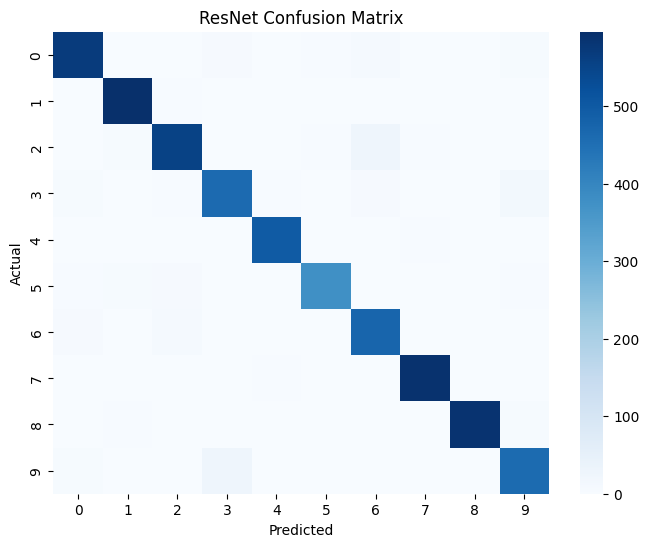

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=False, cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("ResNet Confusion Matrix")
plt.show()